## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.



1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

In [35]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./data/golub.csv")

df["cancer"] = df["cancer"].map({"allB": 0, "allT": 0, "aml": 1})

#drop non ALLB, ALLT, ALL cancer types
df.dropna(subset = ["cancer"], inplace = True)   

ModuleNotFoundError: No module named 'seaborn'


2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 


MSE: 2.8455828920537453e-30


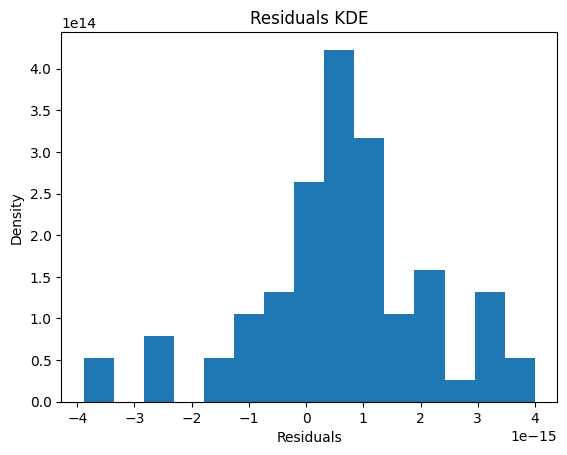

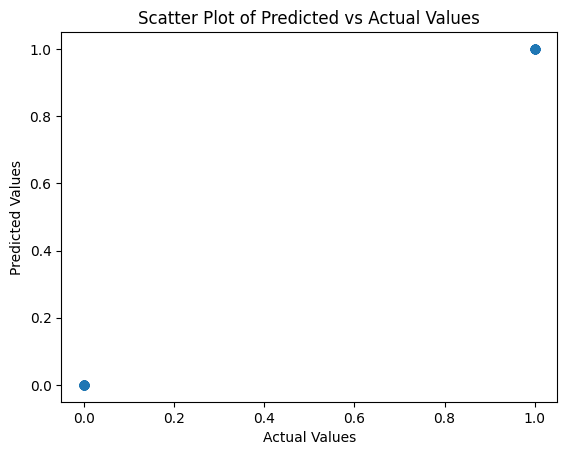

In [34]:
model = LinearRegression()

X = df.drop(columns=["Samples", "BM.PB", "Gender", "Source", "tissue.mf"]).select_dtypes(include="number").fillna(df.mean(numeric_only=True))
y = df["cancer"]

model.fit(X,y)
y_hat = model.predict(X)
r_y = y - y_hat

print("MSE:", mean_squared_error(y, y_hat))

#kde of residuals
plt.figure()
plt.hist(r_y, bins=15, density=True)
plt.title("Residuals KDE")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.show()

#scatter plot
plt.figure()
plt.scatter(y, y_hat)
plt.title("Scatter Plot of Predicted vs Actual Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()



3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.



4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 



5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?



6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.



7. Why do regularization methods lend themselves to scenarios like precision health? 



8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?